In [54]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({'font.size': 16, 'axes.labelsize': 16, 'axes.titlesize': 16, 'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16, 'figure.titlesize': 20}) # change font size for all plots

## linear plots

  0%|          | 0/31 [00:00<?, ?it/s]

0
Folder 0 has no data
1


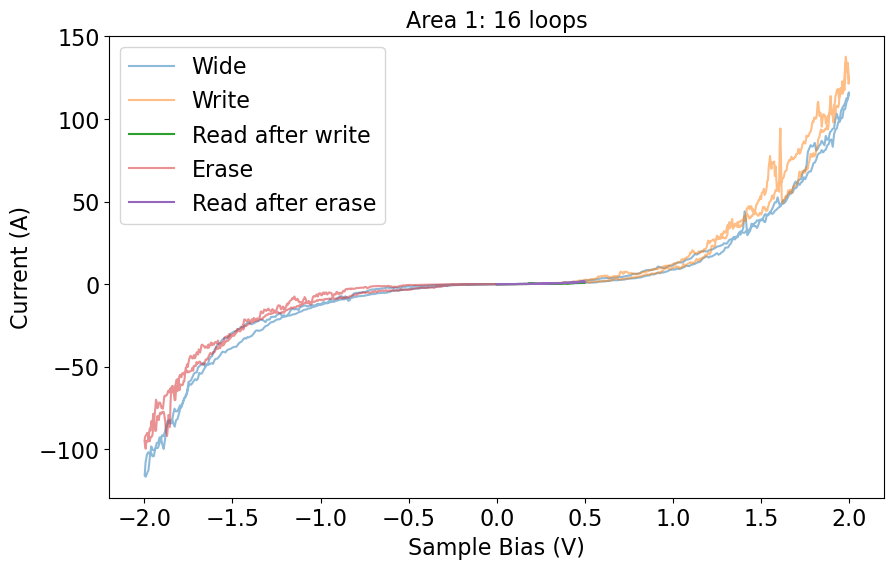

10
Folder 10 has no data
11


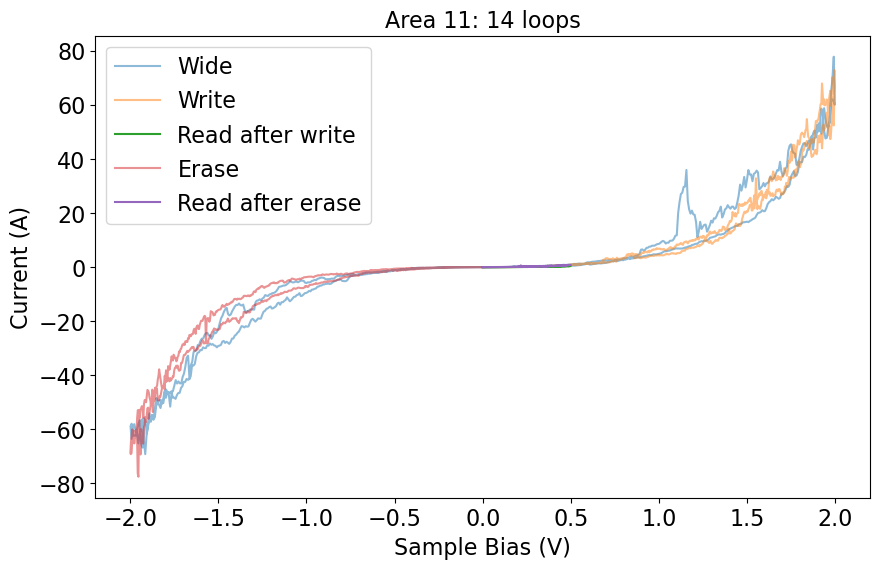

12
Folder 12 has no data
13


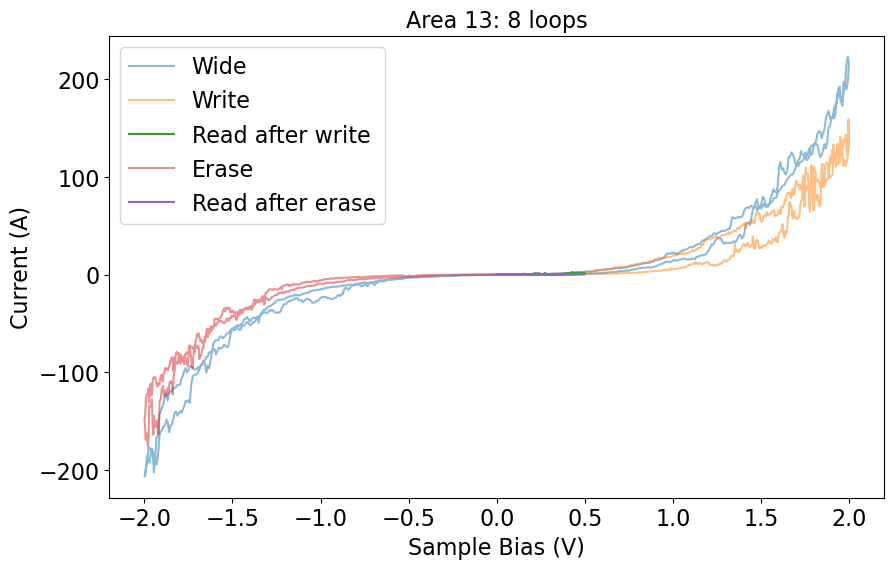

14


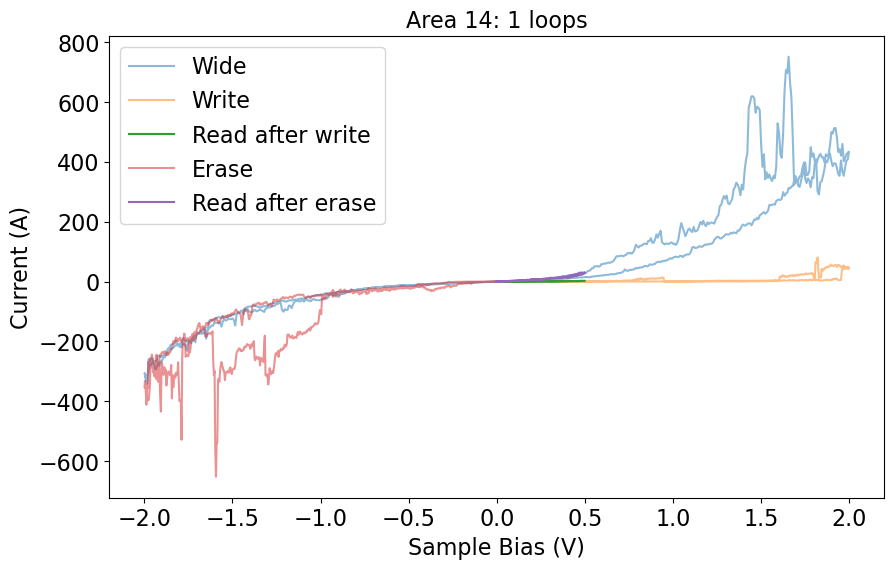

15


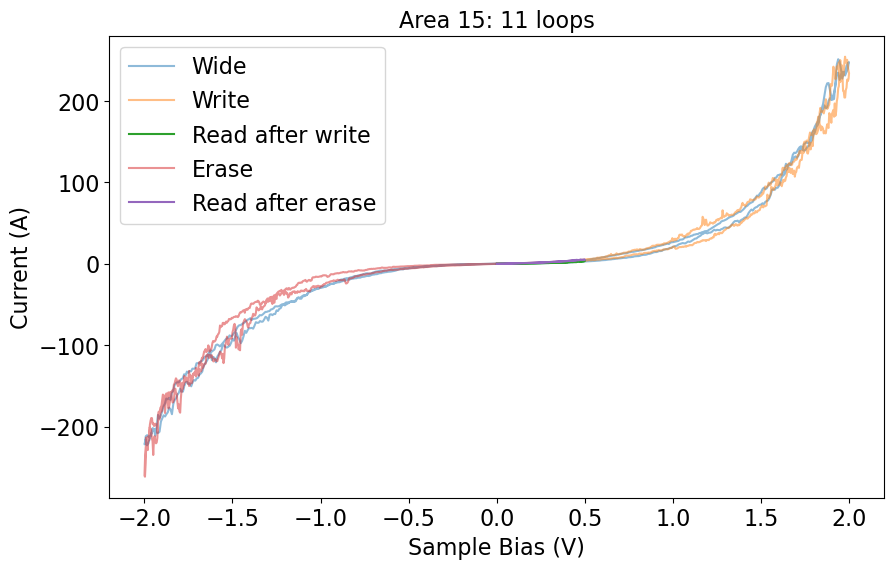

16
Folder 16 has no data
17


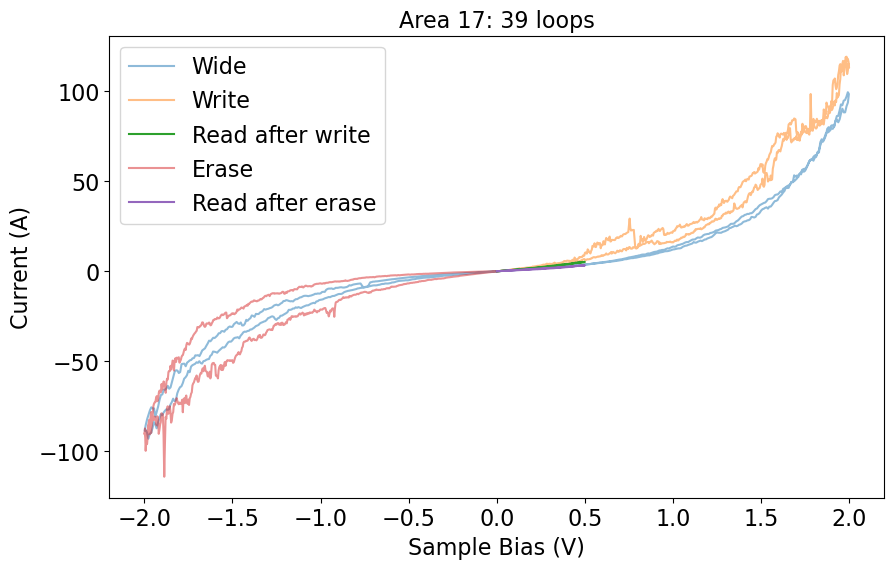

18


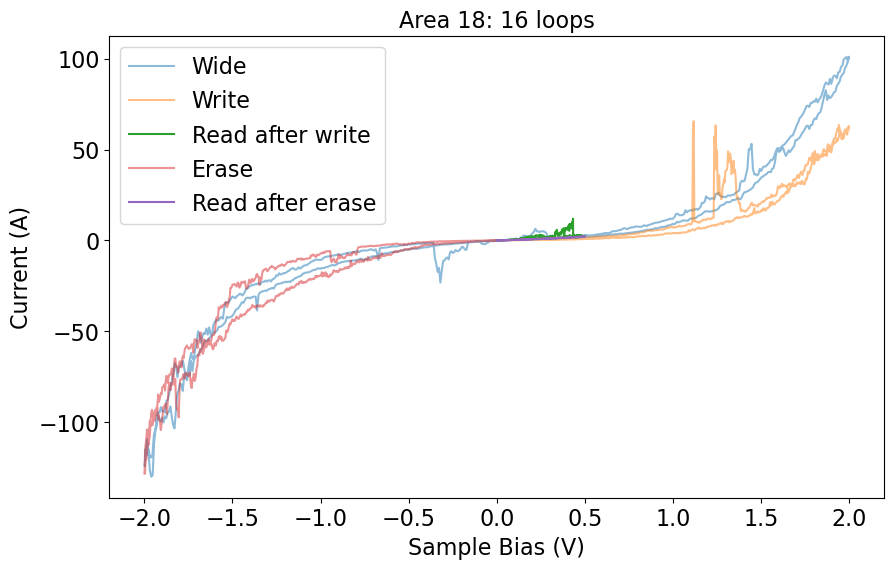

19


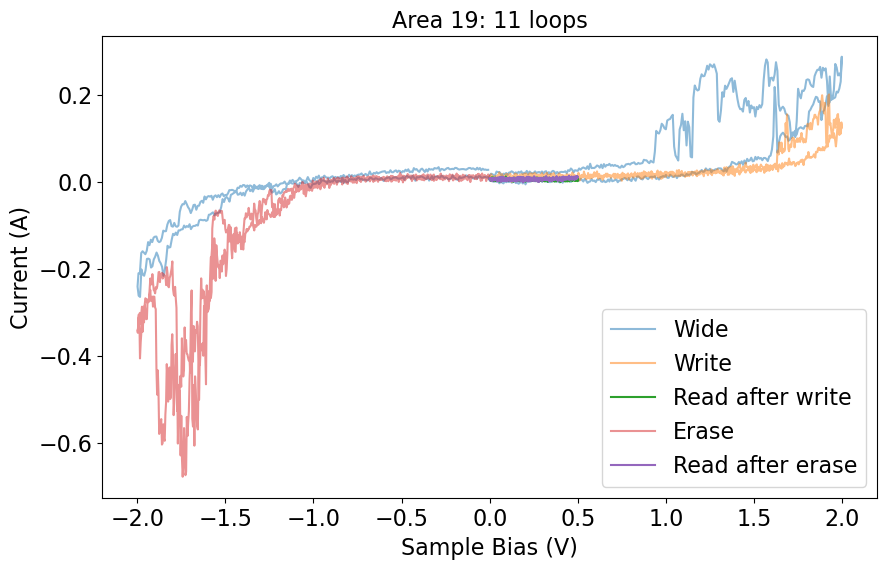

2


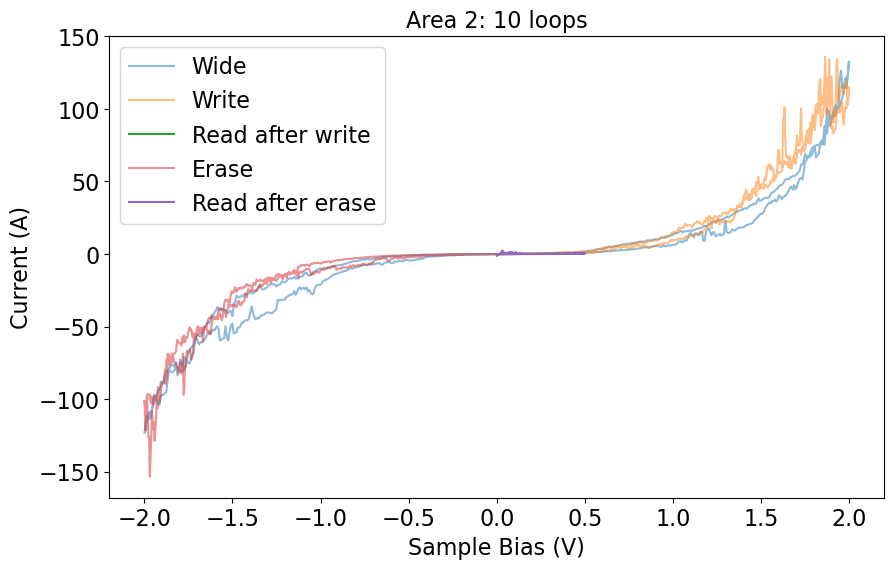

20


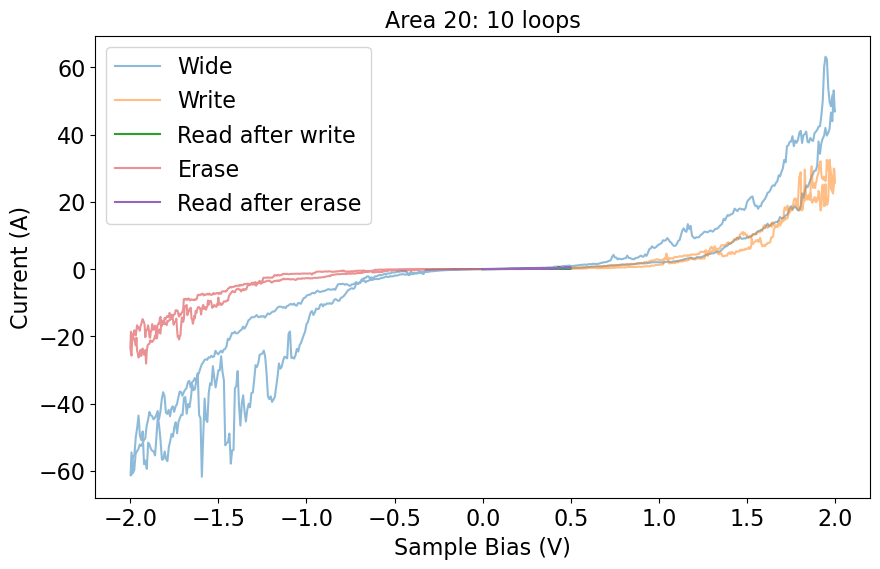

21


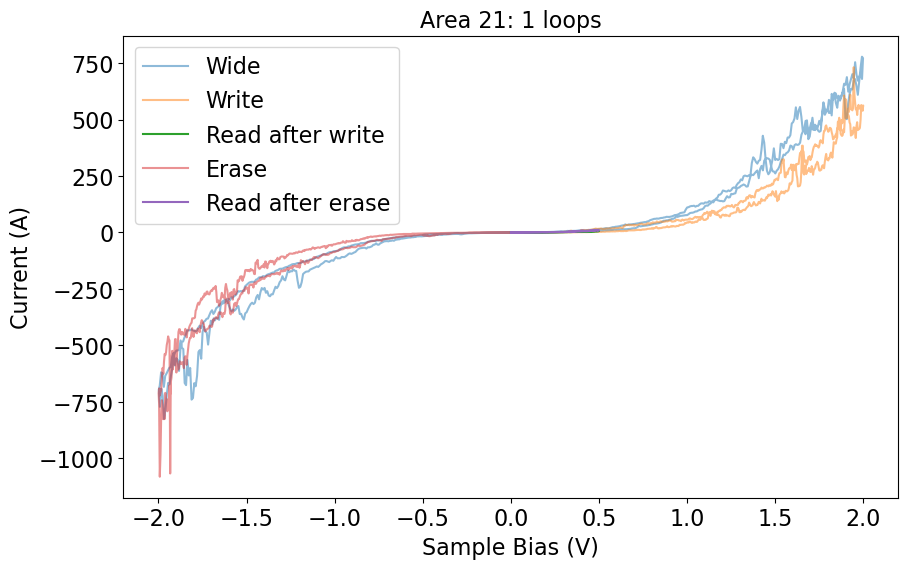

22


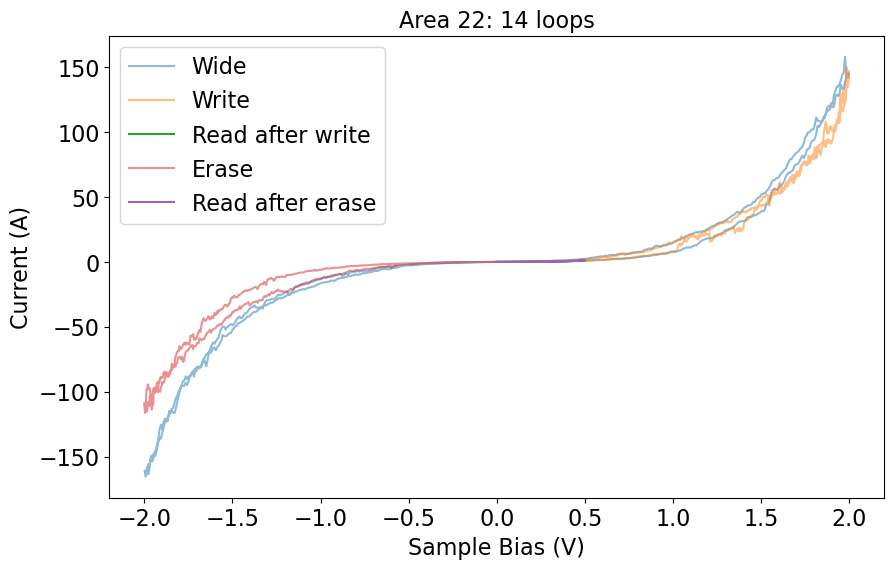

23
Folder 23 has no data
24


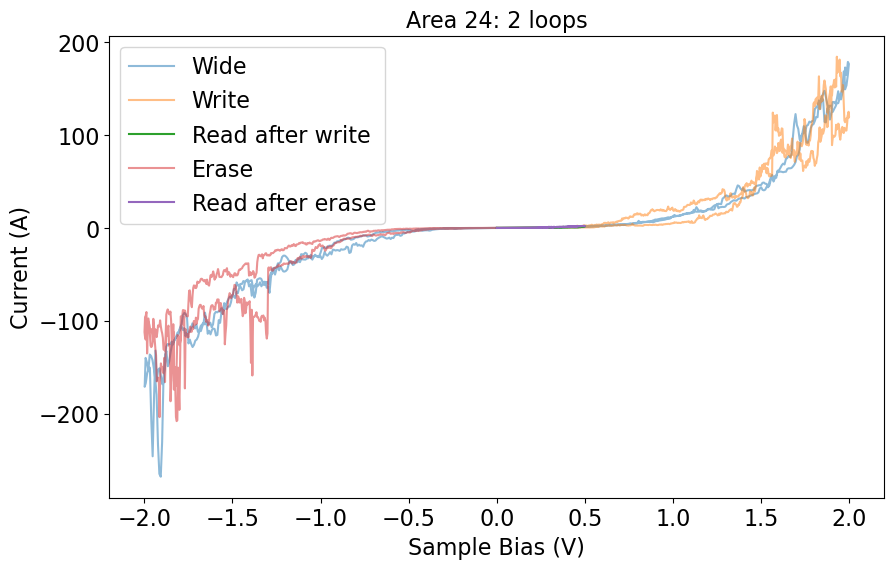

25


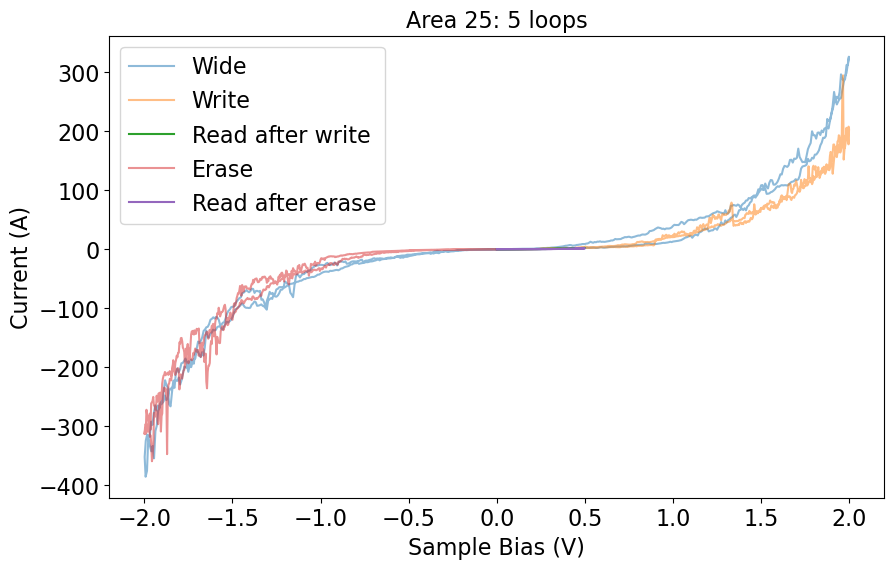

26
Folder 26 has no data
27
Folder 27 has no data
28
Folder 28 has no data
29


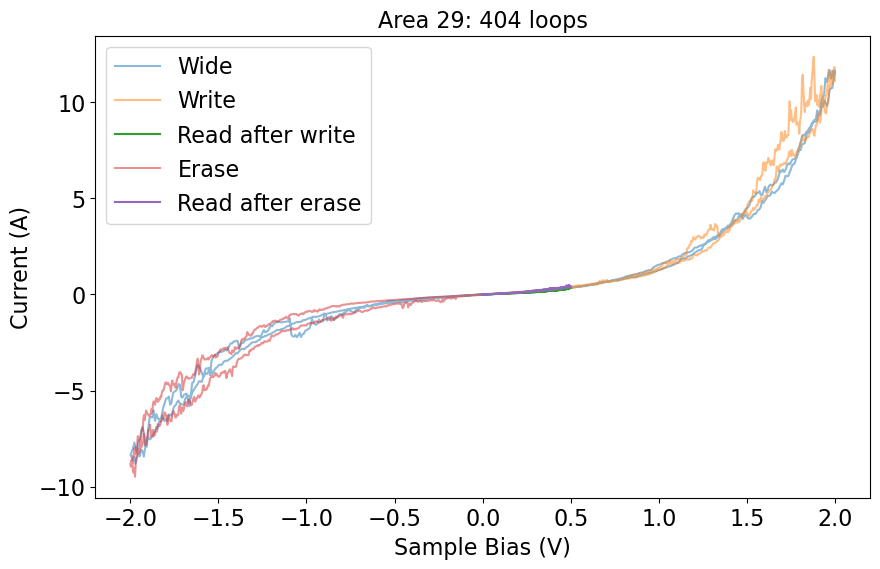

3


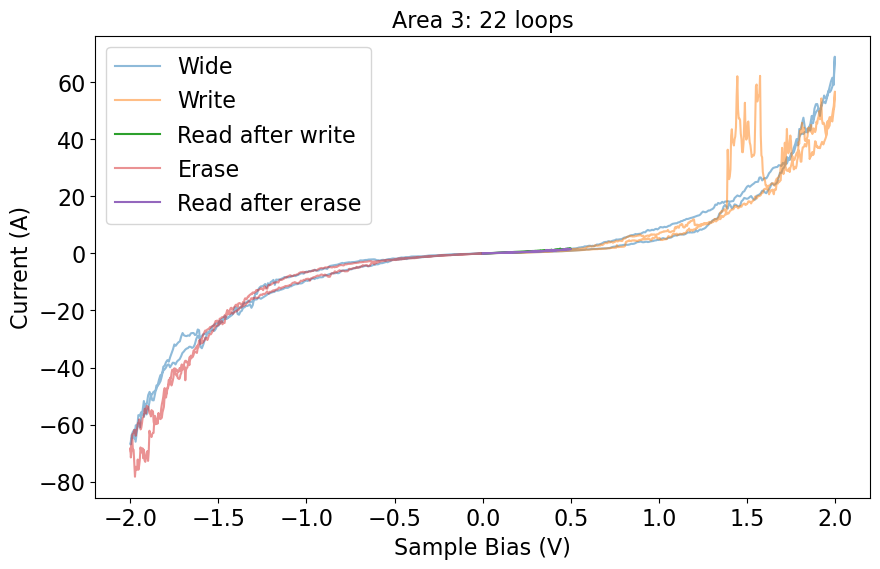

4


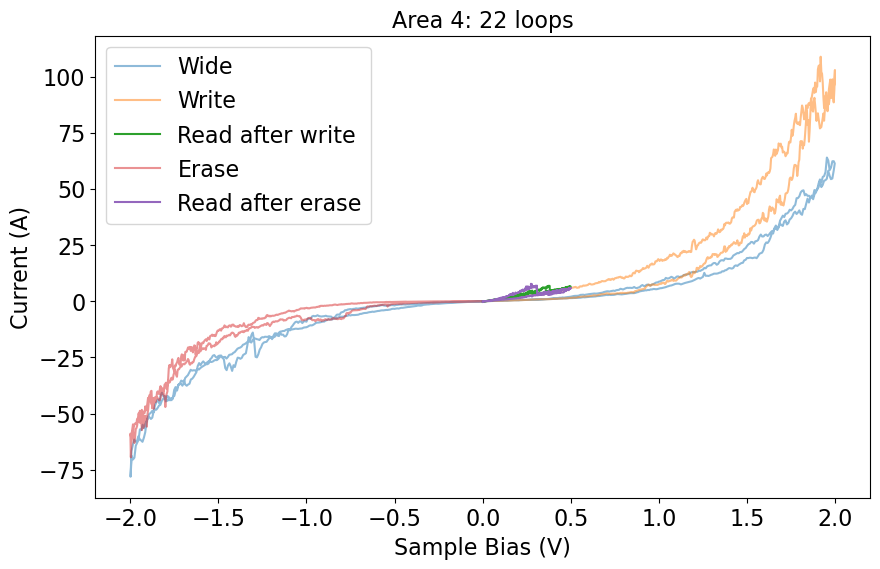

5


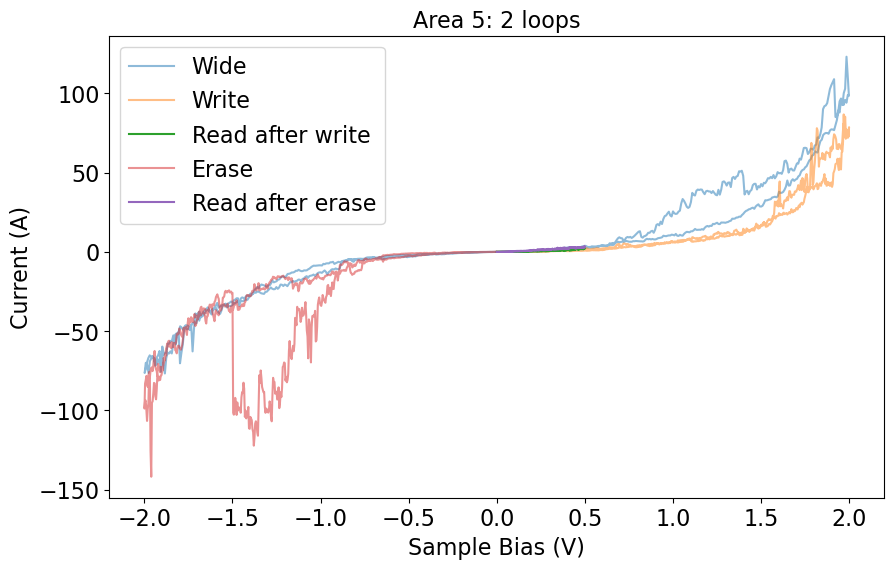

6


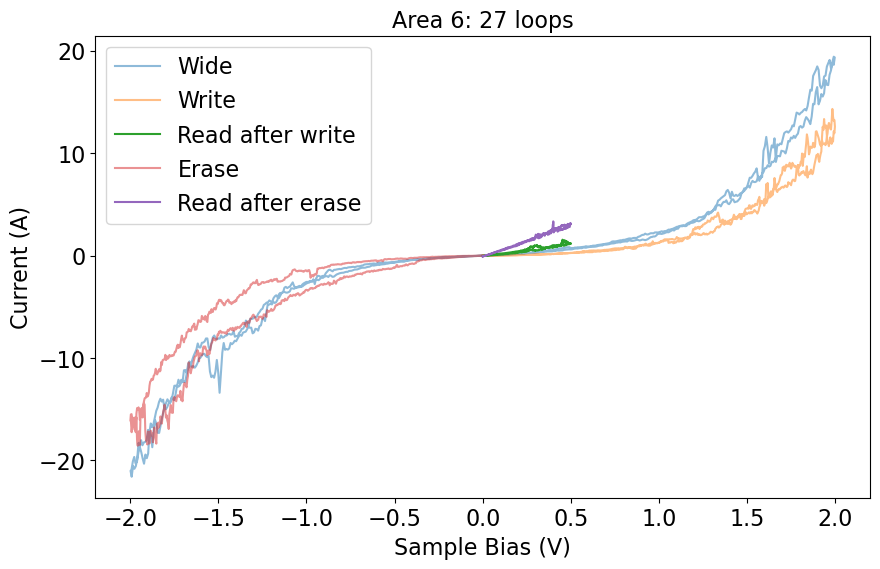

7


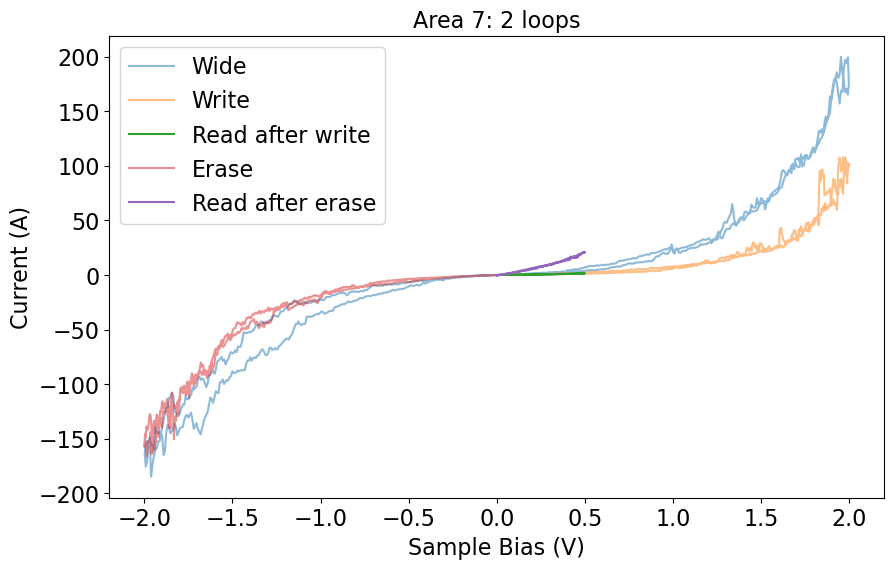

8


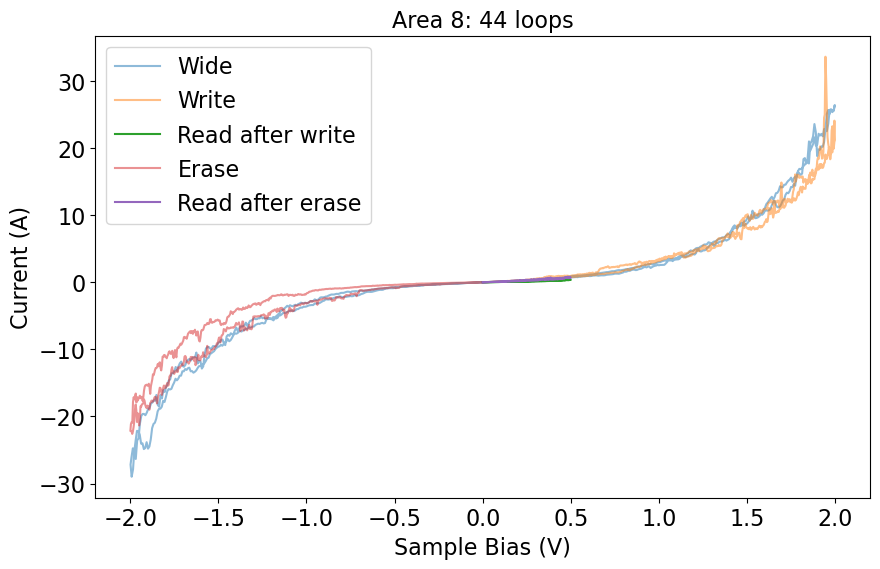

9


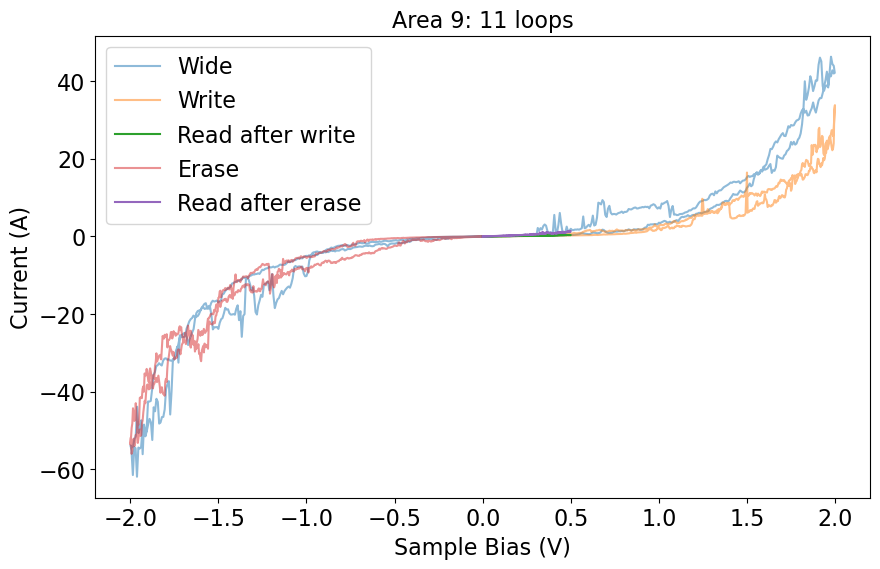

Plots
Folder Plots has no data


In [55]:
baseDir = r"C:\Users\newsonj\OneDrive - Lancaster University\Documents\PhD\Electrospray\Fused Porphyrin\fP2\2026-10-01 new 100ugml 1hr\2026-10-02 JN fP2\CAFM\Memristor script test"
if not os.path.exists(os.path.join(baseDir, "Plots")):
    os.makedirs(os.path.join(baseDir, "Plots"))
if not os.path.exists(os.path.join(baseDir, "Plots", "Linear")):
    os.makedirs(os.path.join(baseDir, "Plots", "Linear"))

sequence = ["WIDE", "WRITE", "READ", "READ", "READ", "READ", "ERASE", "READ", "READ", "READ", "READ", "WIDE"]

folders = sorted(
    f for f in os.listdir(baseDir)
    if os.path.isdir(os.path.join(baseDir, f))
)

for folder in tqdm(folders):
    if not os.path.exists(os.path.join(baseDir, folder, "Processed", "FX40_Spectroscopy_Data_corrected.pkl")):
            continue
    data = pd.read_pickle(os.path.join(baseDir, folder, "Processed", "FX40_Spectroscopy_Data_corrected.pkl"))
    print(folder)
    if len(data) == 0:
        print(f"Folder {folder} has no data")
        continue
    wide = data[data["Type"] == "WIDE"]
    write = data[data["Type"] == "WRITE"]
    readw = data[data["Type"] == "READW"]
    reade = data[data["Type"] == "READE"]
    erase = data[data["Type"] == "ERASE"]

    wideAvg = np.mean(np.array(wide["Current"].tolist()), axis=0)
    writeAvg = np.mean(np.array(write["Current"].tolist()), axis=0)
    readwAvg = np.mean(np.array(readw["Current"].tolist()), axis=0)
    readeAvg = np.mean(np.array(reade["Current"].tolist()), axis=0)
    eraseAvg = np.mean(np.array(erase["Current"].tolist()), axis=0)


    plt.figure(figsize=(10, 6))
    plt.plot(wide["Bias"].iloc[0], wideAvg, alpha=0.5, label = "Wide")
    plt.plot(write["Bias"].iloc[0], writeAvg, alpha=0.5, label = "Write")
    plt.plot(readw["Bias"].iloc[0], readwAvg, alpha=1, label = "Read after write")
    plt.plot(erase["Bias"].iloc[0], eraseAvg, alpha=0.5, label = "Erase")
    plt.plot(reade["Bias"].iloc[0], readeAvg, alpha=1, label = "Read after erase")
    plt.title("Area " + folder + ": " + str(int(len(data)/len(sequence))) + " loops")
    plt.xlabel("Sample Bias (V)")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.savefig(os.path.join(baseDir, folder, "Processed", "linear.png"), dpi=300)
    plt.savefig(os.path.join(baseDir, folder, "Processed", "linear.svg"), dpi=300)
    plt.savefig(os.path.join(baseDir, "Plots", "Linear", f"area {folder}.png"), dpi=300)
    plt.show()


# Logarithmic Plots

  0%|          | 0/31 [00:00<?, ?it/s]

0
Folder 0 has no data
1


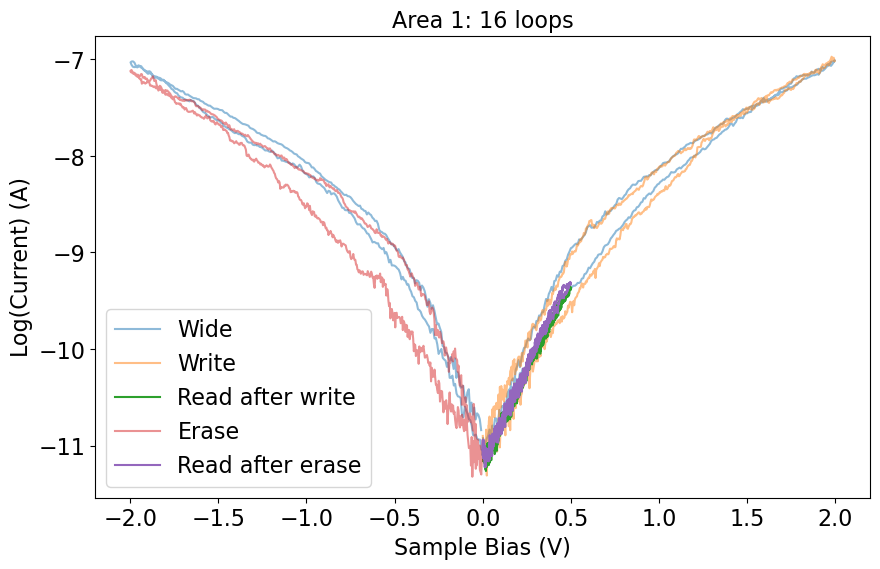

10
Folder 10 has no data
11


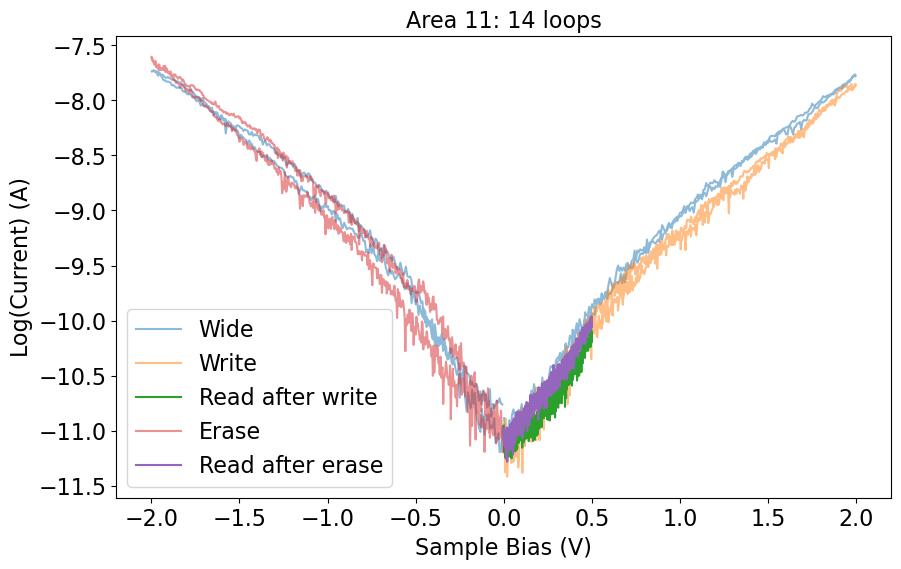

12
Folder 12 has no data
13


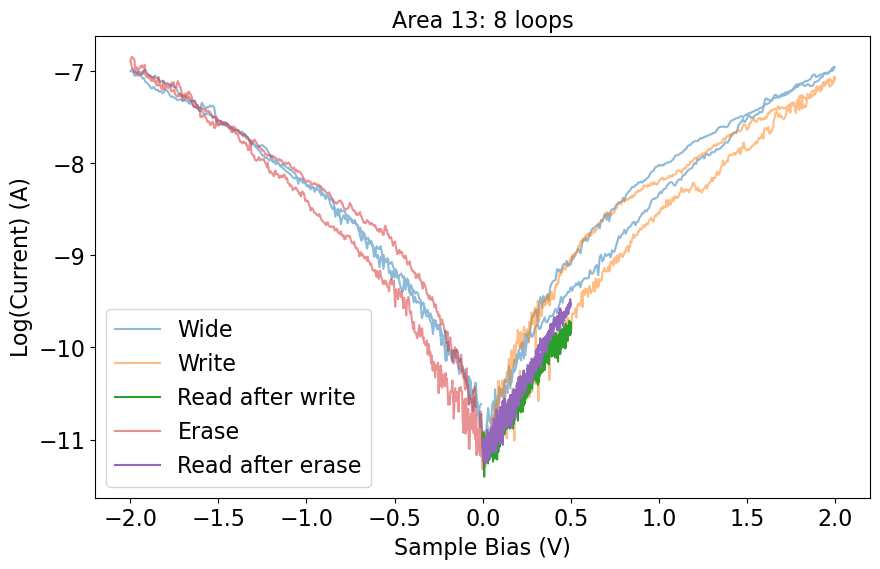

14


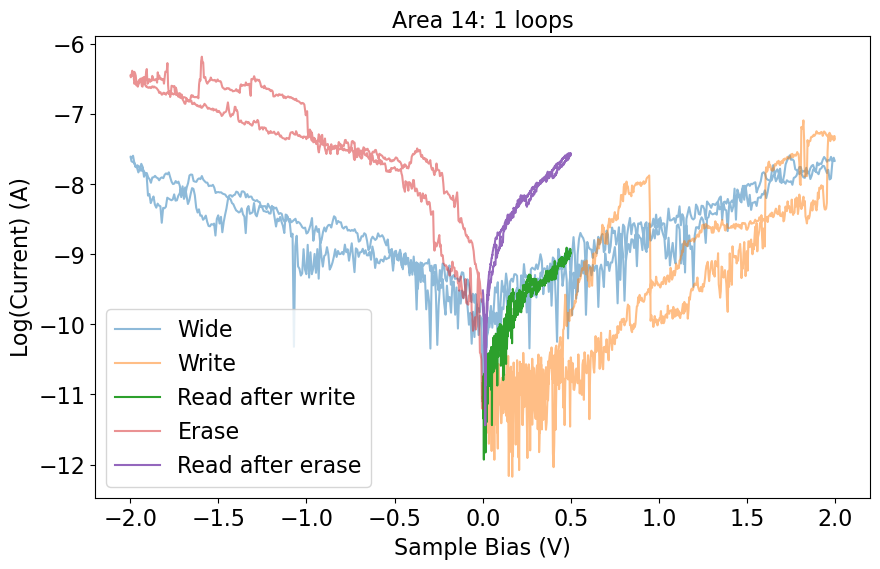

15


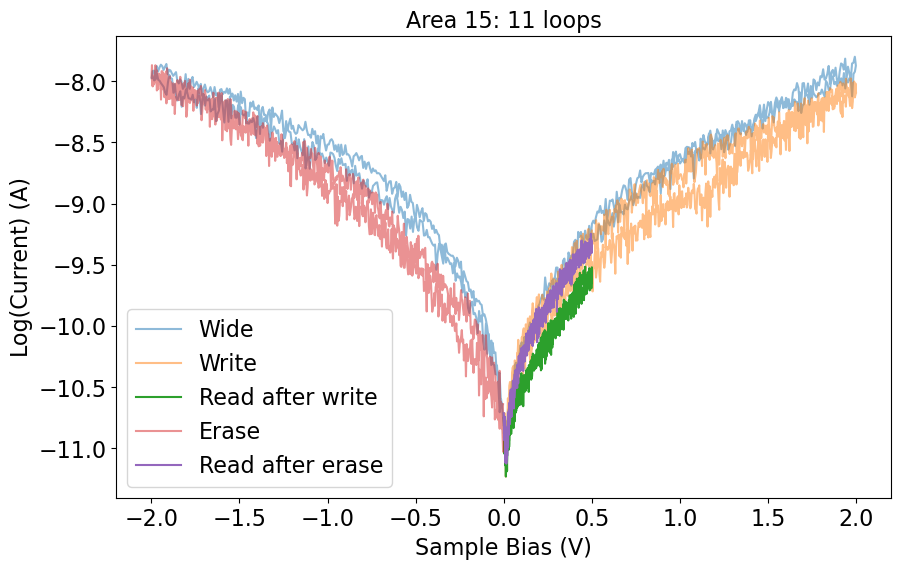

16
Folder 16 has no data
17


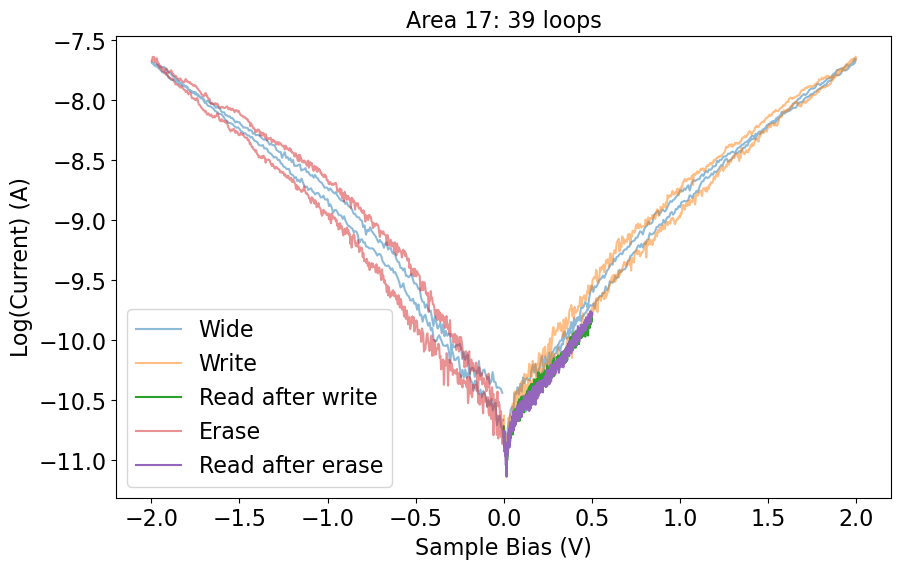

18


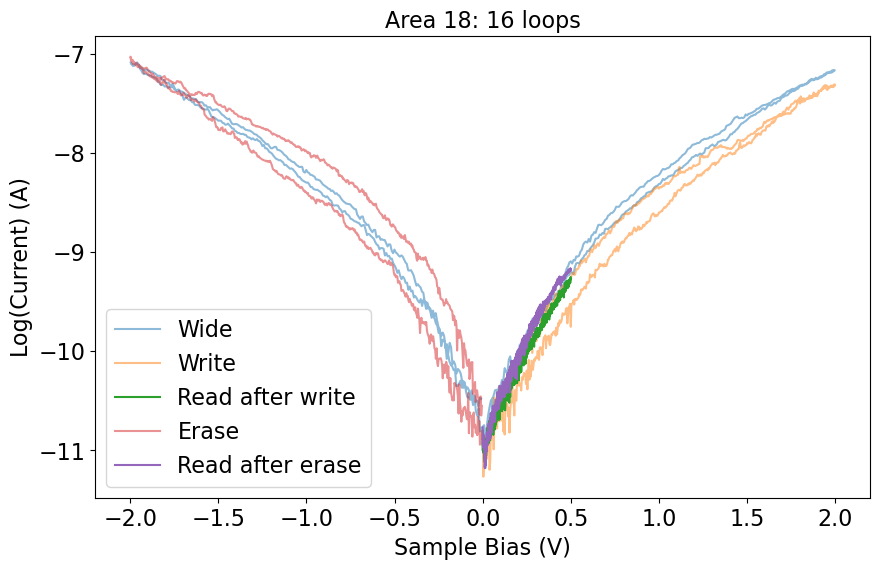

19


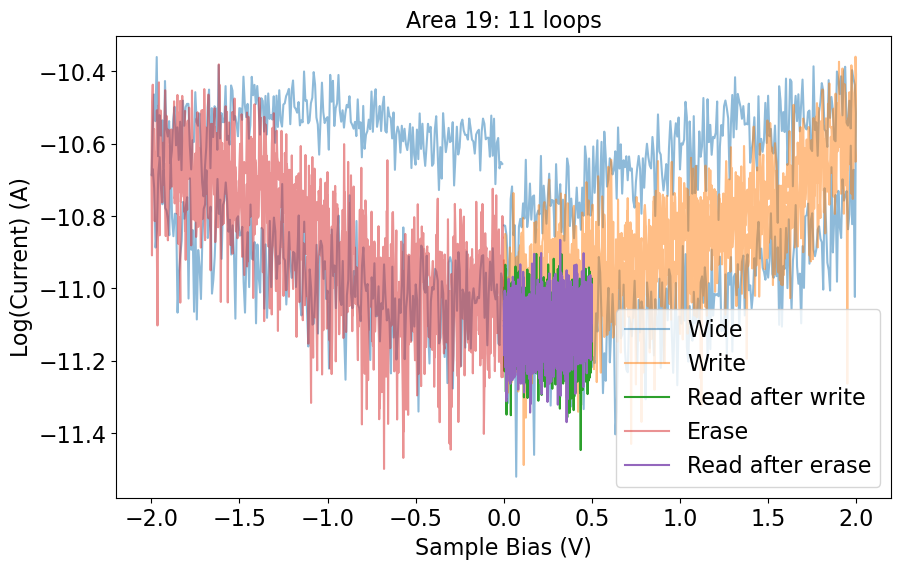

2


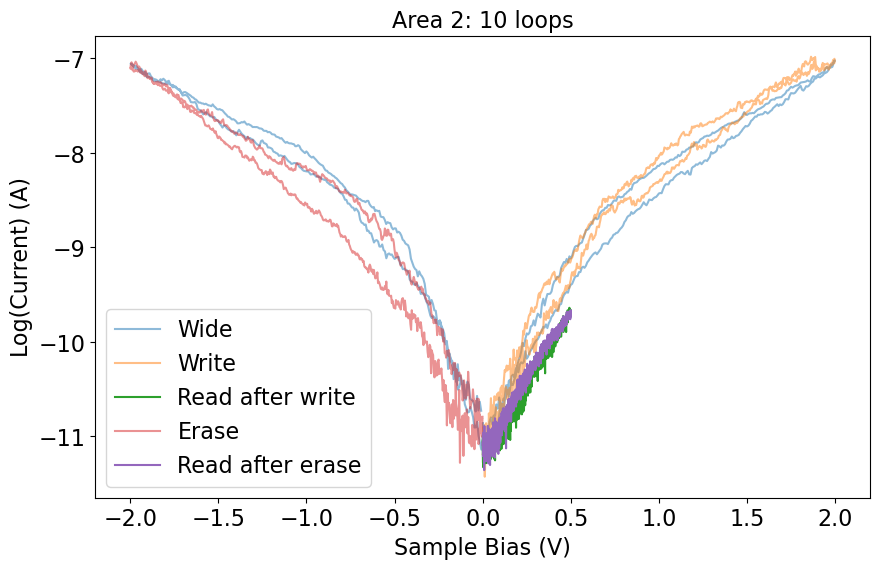

20


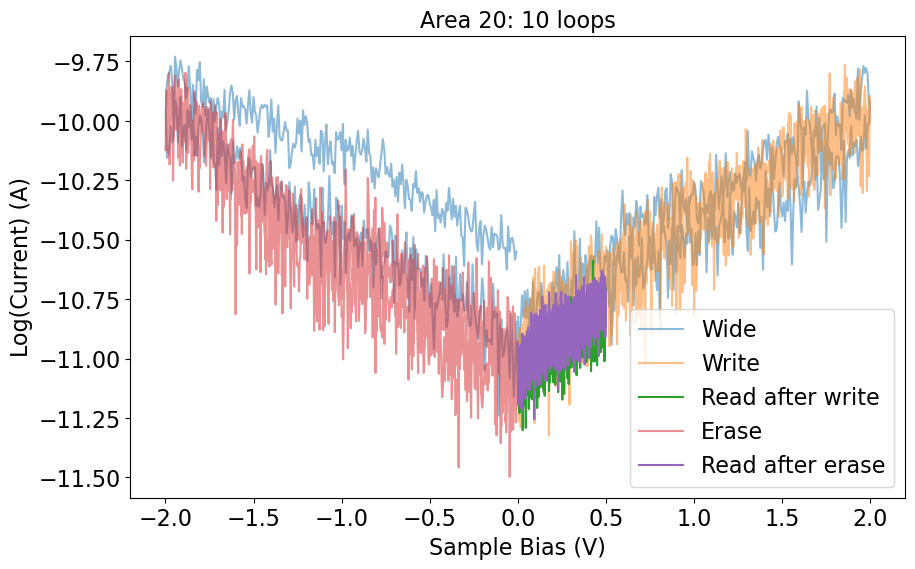

21


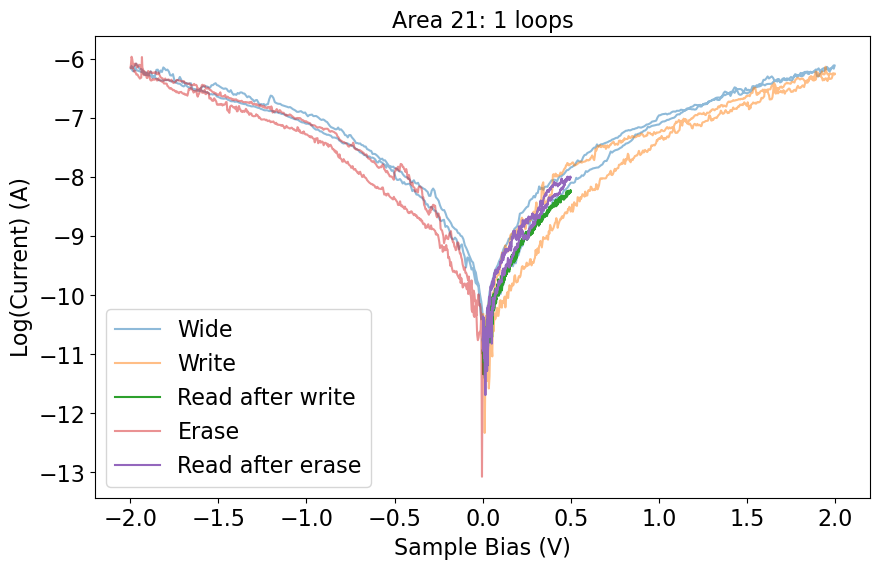

22


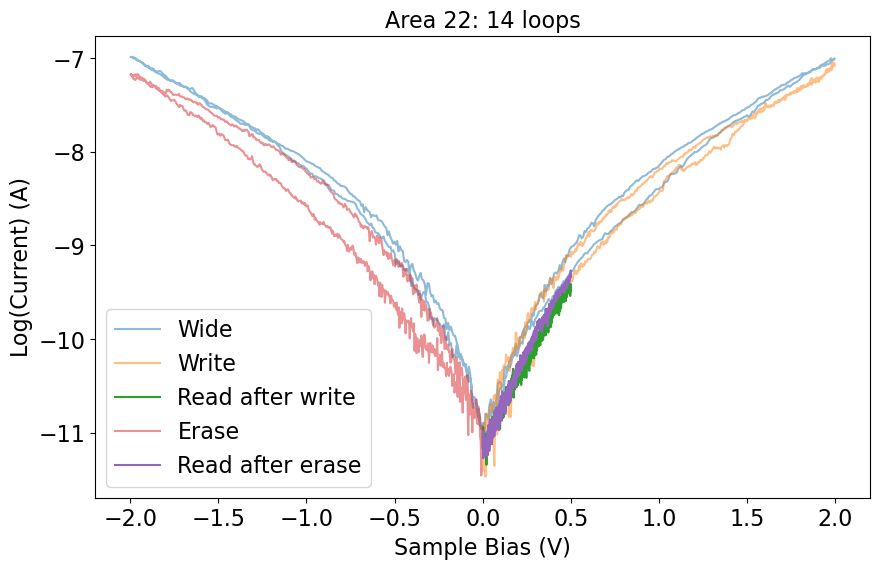

23
Folder 23 has no data
24


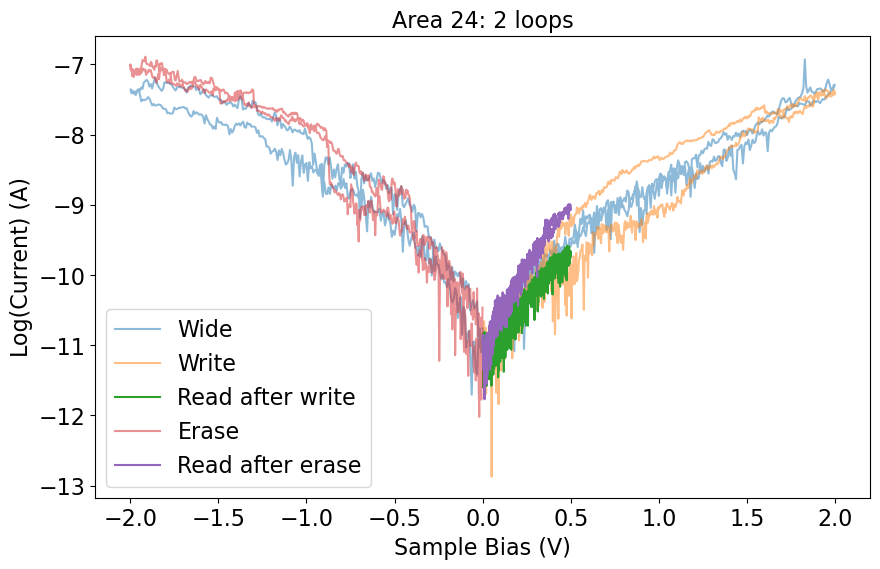

25


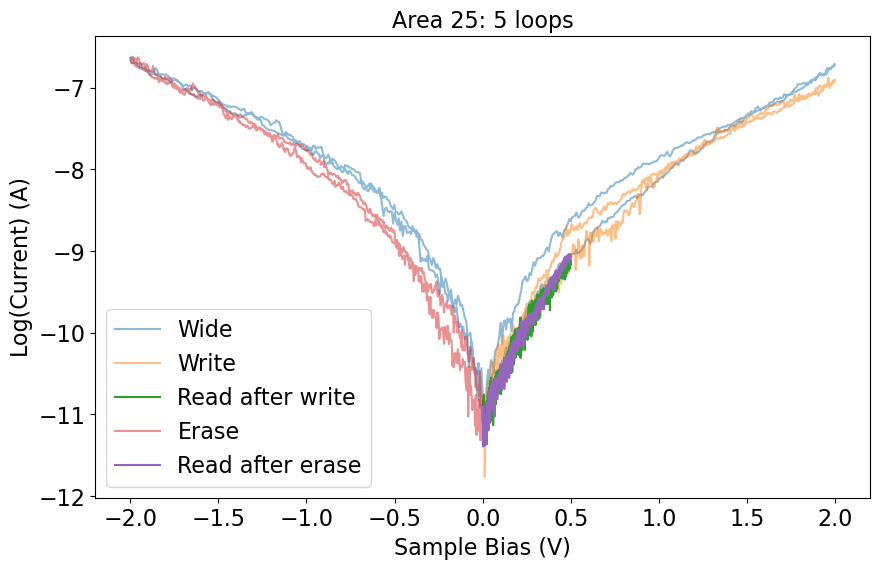

26
Folder 26 has no data
27
Folder 27 has no data
28
Folder 28 has no data
29


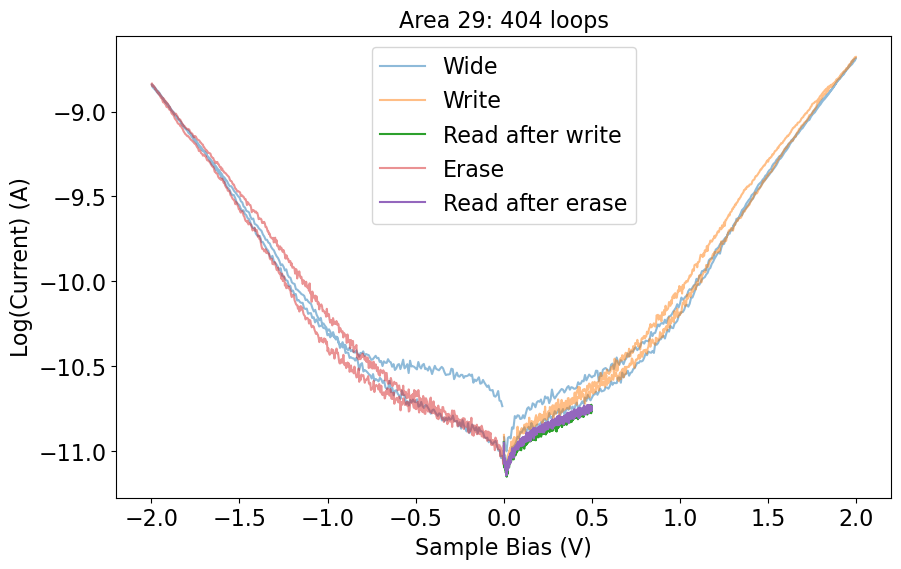

3


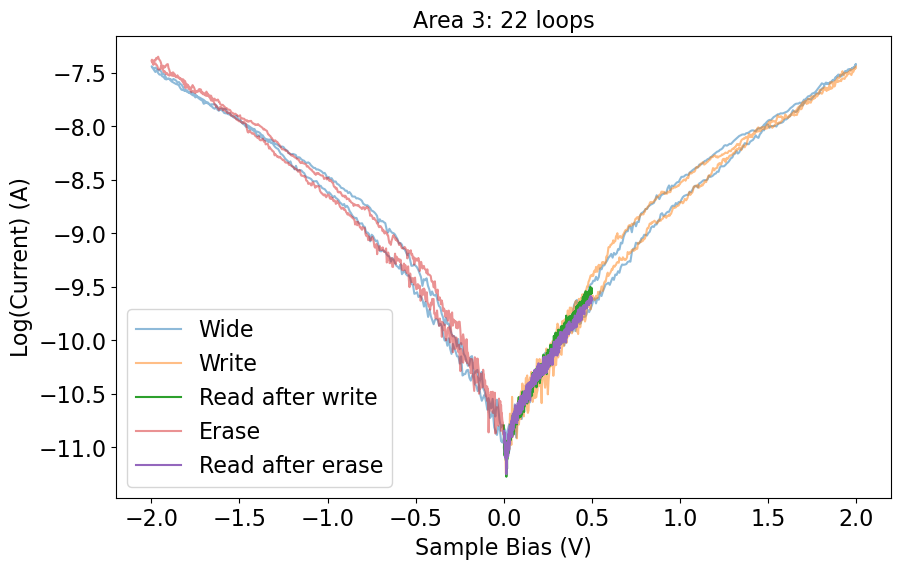

4


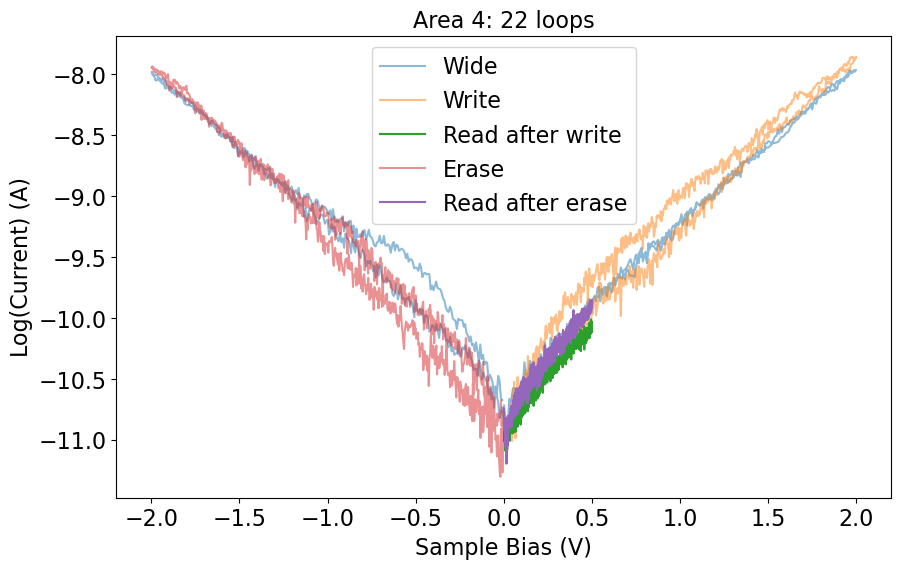

5


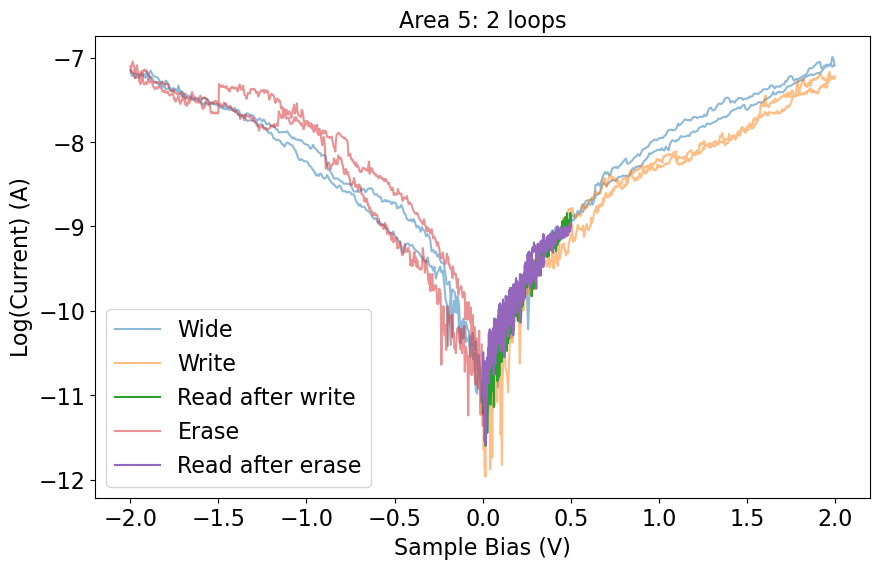

6


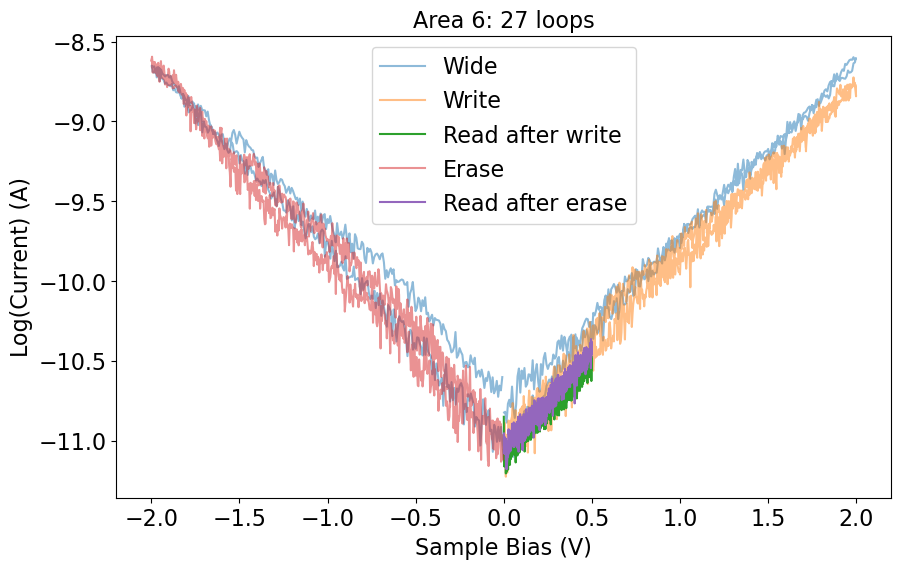

7


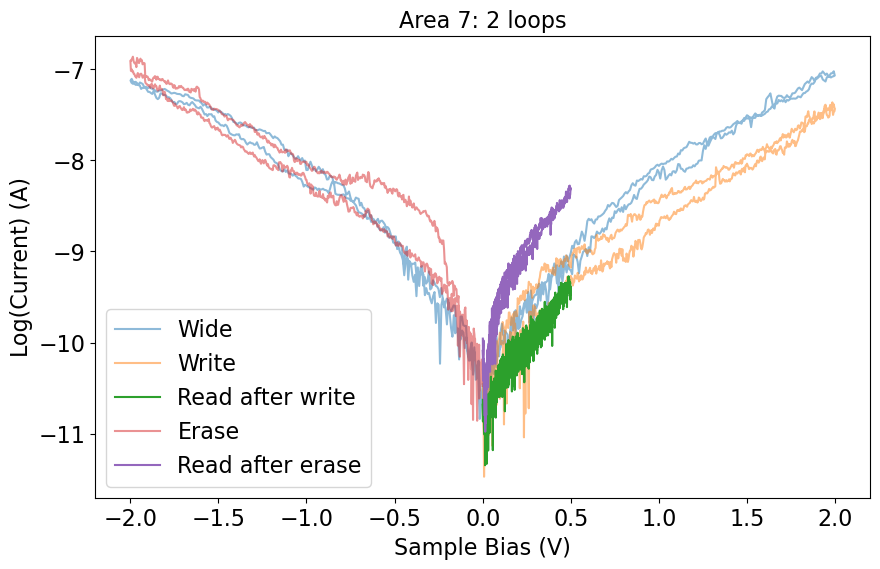

8


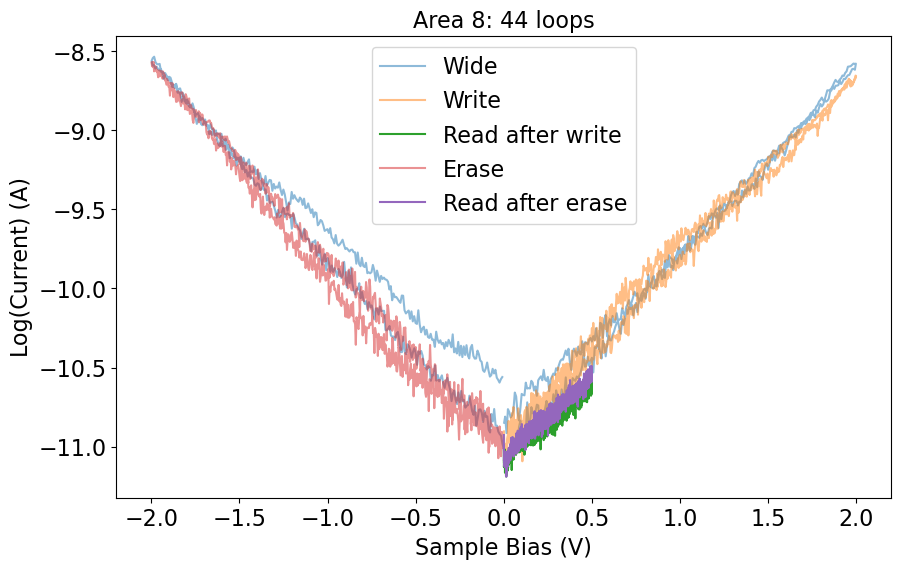

9


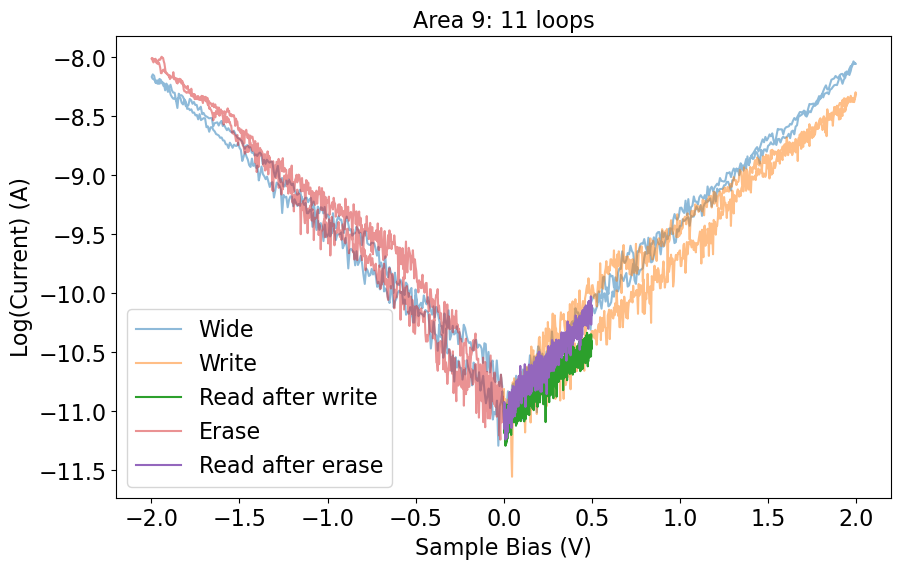

Plots
Folder Plots has no data


In [56]:
baseDir = r"C:\Users\newsonj\OneDrive - Lancaster University\Documents\PhD\Electrospray\Fused Porphyrin\fP2\2026-10-01 new 100ugml 1hr\2026-10-02 JN fP2\CAFM\Memristor script test"
if not os.path.exists(os.path.join(baseDir, "Plots")):
    os.makedirs(os.path.join(baseDir, "Plots"))
if not os.path.exists(os.path.join(baseDir, "Plots", "Log")):
    os.makedirs(os.path.join(baseDir, "Plots", "Log"))

sequence = ["WIDE", "WRITE", "READ", "READ", "READ", "READ", "ERASE", "READ", "READ", "READ", "READ", "WIDE"]

folders = sorted(
    f for f in os.listdir(baseDir)
    if os.path.isdir(os.path.join(baseDir, f))
)

for folder in tqdm(folders):
    if not os.path.exists(os.path.join(baseDir, folder, "Processed", "FX40_Spectroscopy_Data_corrected.pkl")):
        continue
    data = pd.read_pickle(os.path.join(baseDir, folder, "Processed", "FX40_Spectroscopy_Data_corrected.pkl"))
    print(folder)
    if len(data) == 0:
        print(f"Folder {folder} has no data")
        continue
    wide = data[data["Type"] == "WIDE"]
    write = data[data["Type"] == "WRITE"]
    readw = data[data["Type"] == "READW"]
    reade = data[data["Type"] == "READE"]
    erase = data[data["Type"] == "ERASE"]

    wideAvg = np.mean(np.array(wide["Log(Current)"].tolist()), axis=0)
    writeAvg = np.mean(np.array(write["Log(Current)"].tolist()), axis=0)
    readwAvg = np.mean(np.array(readw["Log(Current)"].tolist()), axis=0)
    readeAvg = np.mean(np.array(reade["Log(Current)"].tolist()), axis=0)
    eraseAvg = np.mean(np.array(erase["Log(Current)"].tolist()), axis=0)


    plt.figure(figsize=(10, 6))
    plt.plot(wide["Bias"].iloc[0], wideAvg, alpha=0.5, label = "Wide")
    plt.plot(write["Bias"].iloc[0], writeAvg, alpha=0.5, label = "Write")
    plt.plot(readw["Bias"].iloc[0], readwAvg, alpha=1, label = "Read after write")
    plt.plot(erase["Bias"].iloc[0], eraseAvg, alpha=0.5, label = "Erase")
    plt.plot(reade["Bias"].iloc[0], readeAvg, alpha=1, label = "Read after erase")
    plt.title("Area " + folder + ": " + str(int(len(data)/len(sequence))) + " loops")
    plt.xlabel("Sample Bias (V)")
    plt.ylabel("Log(Current) (A)")
    plt.legend()
    plt.savefig(os.path.join(baseDir, folder, "Processed", "log.png"), dpi=300)
    plt.savefig(os.path.join(baseDir, folder, "Processed", "log.svg"), dpi=300)
    plt.savefig(os.path.join(baseDir, "Plots", "Log", f"area {folder}.png"), dpi=300)
    plt.show()